In [175]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

In [176]:
sns.set_style('darkgrid')
df = pd.read_csv('train.csv')

print("--- First 5 Row ---")
display(df.head())

print("\n--- Dataset Information ---")
df.info()

print("\n--- Statistical Summary ---")
display(df.describe().T)

--- First 5 Row ---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64


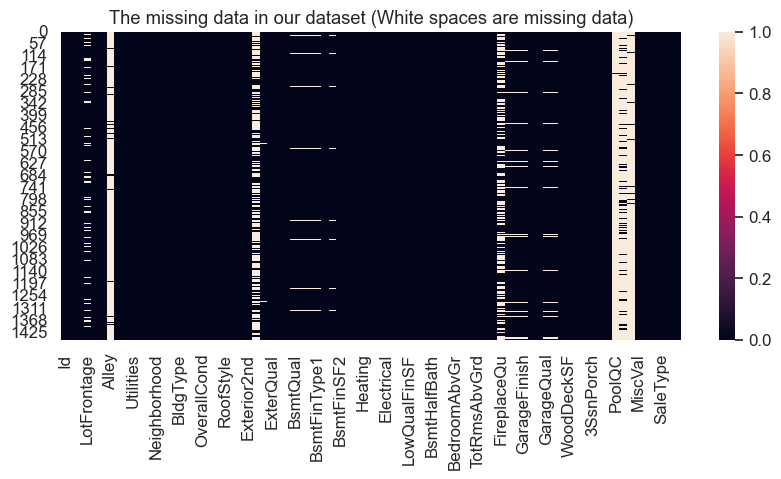

In [177]:
    print(df.isnull().sum().sort_values(ascending=False).head(20))
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=True, yticklabels=57)
    plt.title("The missing data in our dataset (White spaces are missing data)")
    plt.yticks(rotation=0)
    plt.show()

In [178]:
df = df.drop('Id', axis=1)
df = df.drop('Alley', axis=1)
df = df.drop('PoolQC', axis=1)
df = df.drop('Exterior2nd', axis=1)
df = df.drop('FireplaceQu', axis=1)
df = df.drop('MiscFeature', axis=1)
df = df.drop('Fence', axis=1)
df = df.drop('MasVnrType', axis=1)

MSSubClass      -0.386347
LotFrontage      1.000000
LotArea          0.426095
OverallQual      0.251646
OverallCond     -0.059213
YearBuilt        0.123349
YearRemodAdd     0.088866
MasVnrArea       0.193458
BsmtFinSF1       0.233633
BsmtFinSF2       0.049900
BsmtUnfSF        0.132644
TotalBsmtSF      0.392075
1stFlrSF         0.457181
2ndFlrSF         0.080177
LowQualFinSF     0.038469
GrLivArea        0.402797
BsmtFullBath     0.100949
BsmtHalfBath    -0.007234
FullBath         0.198769
HalfBath         0.053532
BedroomAbvGr     0.263170
KitchenAbvGr    -0.006069
TotRmsAbvGrd     0.352096
Fireplaces       0.266639
GarageYrBlt      0.070250
GarageCars       0.285691
GarageArea       0.344997
WoodDeckSF       0.088521
OpenPorchSF      0.151972
EnclosedPorch    0.010700
3SsnPorch        0.070029
ScreenPorch      0.041383
PoolArea         0.206167
MiscVal          0.003368
MoSold           0.011200
YrSold           0.007450
SalePrice        0.351799
Name: LotFrontage, dtype: float64


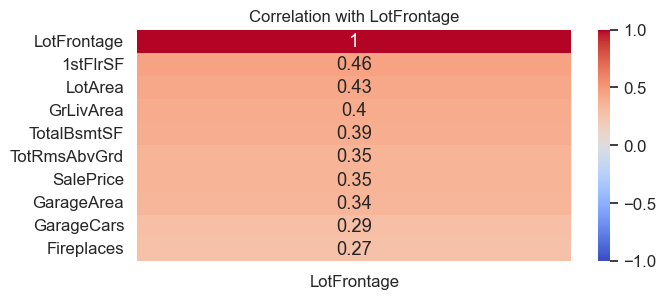

In [179]:
print(df.corr(numeric_only=True)['LotFrontage'])

lot_corr = df.corr(numeric_only=True)[['LotFrontage']].sort_values(by='LotFrontage', ascending=False)
top_corr = lot_corr.head(10)

plt.figure(figsize=(7, 3)) 
sns.heatmap(top_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title("Correlation with LotFrontage", fontsize=12)
plt.show()

In [180]:
non_null = df[df['LotFrontage'].notnull()]
null_rows = df[df['LotFrontage'].isnull()]
model = LinearRegression()
model.fit(non_null[['1stFlrSF']], non_null['LotFrontage'])
preds = model.predict(null_rows[['1stFlrSF']])
df.loc[df['LotFrontage'].isnull(), 'LotFrontage'] = preds

for col in ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']:
    df[col] = df[col].fillna('None')

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

for col in ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']:
    df[col] = df[col].fillna('None')

df = df.dropna(subset=['Electrical']) 
df = df.dropna()

In [181]:
ordinal_cols = [
    'ExterQual','ExterCond','BsmtQual','BsmtCond','KitchenQual','HeatingQC',
    'Functional','GarageFinish','BsmtExposure','BsmtFinType1','BsmtFinType2',
    'GarageQual','GarageCond'
]
obj_cols = df.select_dtypes(include=['object']).columns
for col in ordinal_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
nominal_cols = [c for c in obj_cols if c not in ordinal_cols]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [182]:
x = df.drop('SalePrice', axis=1)
y = df['SalePrice']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
num_cols = x_train.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model_results = {}


--- RANDOM FOREST RESULTS ---
RMSE: 21303.24
R2 Score: %91.87
Error rate (RMSE / Mean): %11.79


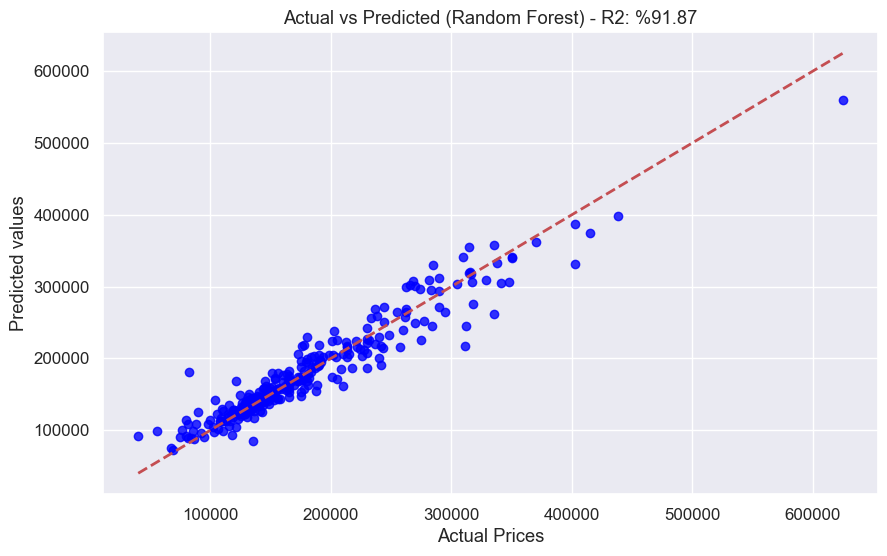


K-Fold using in Random Forest
------------------------------
RMSE = 31823
Error = %17.62
R2 Score: %83.97


In [183]:
print("\n--- RANDOM FOREST RESULTS ---")
rf_model = RandomForestRegressor(
    n_estimators=300,       
    max_depth=20,          
    min_samples_split=5,   
    min_samples_leaf=2,    
    max_features=None,   
    random_state=42
)
rf_model.fit(x_train, y_train)
rf_preds = rf_model.predict(x_test)

rf_rmse = root_mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)
model_results['Random Forest'] = rf_rmse

print(f"RMSE: {rf_rmse:.2f}")
print(f"R2 Score: %{rf_r2*100:.2f}")
print(f"Error rate (RMSE / Mean): %{100 * (rf_rmse / df['SalePrice'].mean()):.2f}")

plt.figure(figsize=(10,6))
plt.scatter(x=y_test, y=rf_preds, alpha=0.8, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Actual vs Predicted (Random Forest) - R2: %{rf_r2*100:.2f}")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted values")
plt.show()


print("\nK-Fold using in Random Forest")
print("------------------------------")
cv_scores_rf = -cross_val_score(rf_model, x_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
print(f"RMSE = {cv_scores_rf.mean():.0f}")
print(f"Error = %{100 * (cv_scores_rf.mean() / df['SalePrice'].mean()):.2f}")
cv_scores_r2 = cross_val_score(rf_model, x_train, y_train, cv=kf, scoring='r2')
print(f"R2 Score: %{cv_scores_r2.mean()*100:.2f}")

In [184]:
print("\n--- The Control of Overfitting (Random Forest) ---")
y_train_preds = rf_model.predict(x_train)
train_rmse = root_mean_squared_error(y_train, y_train_preds)

print(f"Train RMSE: {train_rmse:.0f}")
print(f"Test RMSE: {rf_rmse:.0f}") 
print(f"Fark: {rf_rmse - train_rmse:.0f}")


--- The Control of Overfitting (Random Forest) ---
Train RMSE: 14717
Test RMSE: 21303
Fark: 6586



--- XGBOOST RESULTS ---
RMSE: 19357.40
R2 Score: %93.28
Error rate (RMSE / Mean): %10.72


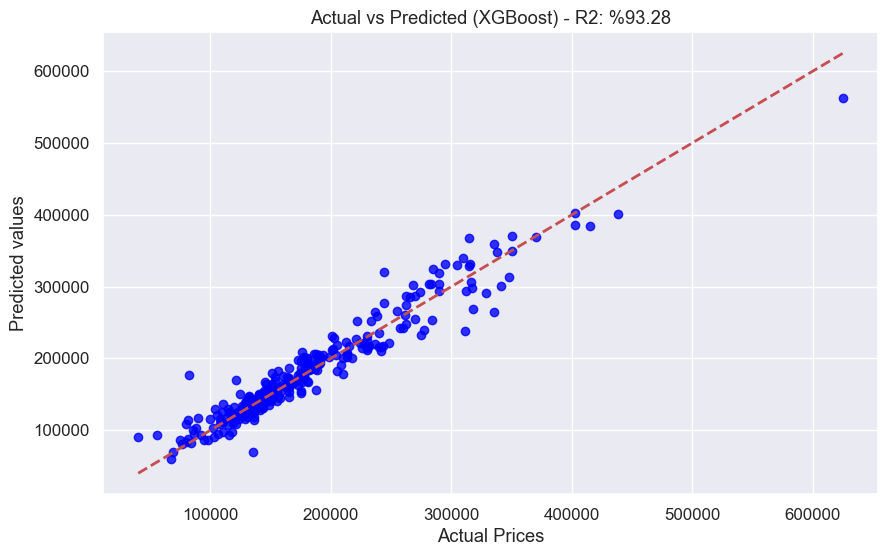


K-Fold using in XgBoost
------------------------
RMSE = 27939
Error = %15.47
R2 Score: %87.71


In [185]:
print("\n--- XGBOOST RESULTS ---")
xgb_model = XGBRegressor(
    n_estimators=2000,      
    learning_rate=0.01,     
    max_depth=4,           
    subsample=0.7,          
    colsample_bytree=0.7,   
    reg_alpha=10,           
    reg_lambda=10,          
    gamma=0.5,           
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(x_train, y_train)
xgb_preds = xgb_model.predict(x_test)

xgb_rmse = root_mean_squared_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)
model_results['XGBoost'] = xgb_rmse

print(f"RMSE: {xgb_rmse:.2f}")
print(f"R2 Score: %{xgb_r2*100:.2f}")


print(f"Error rate (RMSE / Mean): %{100 * (xgb_rmse / df['SalePrice'].mean()):.2f}")

plt.figure(figsize=(10,6))
plt.scatter(x=y_test, y=xgb_preds, alpha=0.8, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Actual vs Predicted (XGBoost) - R2: %{xgb_r2*100:.2f}")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted values")
plt.show()


print("\nK-Fold using in XgBoost")
print("------------------------")
cv_scores_xgb = -cross_val_score(xgb_model, x_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
print(f"RMSE = {cv_scores_xgb.mean():.0f}")
print(f"Error = %{100 * (cv_scores_xgb.mean() / df['SalePrice'].mean()):.2f}")
cv_scores_r2 = cross_val_score(xgb_model, x_train, y_train, cv=kf, scoring='r2')
print(f"R2 Score: %{cv_scores_r2.mean()*100:.2f}")

In [186]:
print("\n--- The Control of Overfitting (XGBoost) ---")
y_train_preds_xgb = xgb_model.predict(x_train)
train_rmse_xgb = root_mean_squared_error(y_train, y_train_preds_xgb)

print(f"Eğitim Seti Hatası (Train RMSE): {train_rmse_xgb:.0f}")
print(f"Test Seti Hatası (Test RMSE):    {xgb_rmse:.0f}")
print(f"Fark: {xgb_rmse - train_rmse_xgb:.0f}")


--- The Control of Overfitting (XGBoost) ---
Eğitim Seti Hatası (Train RMSE): 10428
Test Seti Hatası (Test RMSE):    19357
Fark: 8929


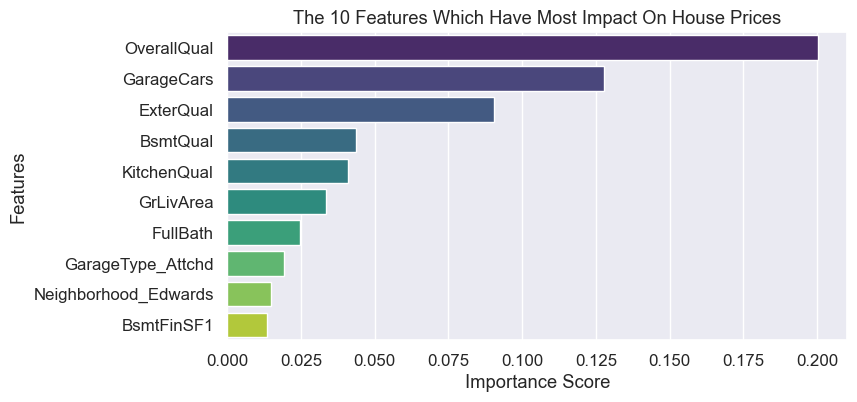

In [187]:
feature_imp = pd.Series(xgb_model.feature_importances_, index=x_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=feature_imp, y=feature_imp.index, hue=feature_imp.index, palette="viridis" , legend=False)
plt.title("The 10 Features Which Have Most Impact On House Prices")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


--- PCA RESULTS (Experimental) ---
Number of features (columns) after PCA: 50 (Original: 179)
RMSE: 26417.09
R2 Score: %87.49
Error (RMSE / Mean): %14.63


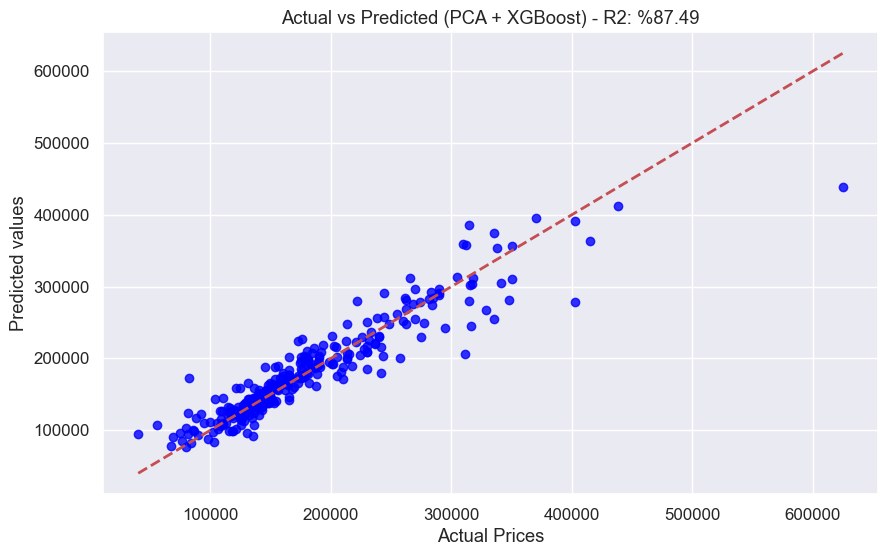

In [188]:
print("\n--- PCA RESULTS (Experimental) ---")


pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

print(f"Number of features (columns) after PCA: {x_train_pca.shape[1]} (Original: {x_train.shape[1]})")

model_pca = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_pca.fit(x_train_pca, y_train)
pca_preds = model_pca.predict(x_test_pca)

pca_rmse = root_mean_squared_error(y_test, pca_preds)
pca_r2 = r2_score(y_test, pca_preds)
model_results['PCA + XGBoost'] = pca_rmse

print(f"RMSE: {pca_rmse:.2f}")
print(f"R2 Score: %{pca_r2*100:.2f}")
print(f"Error (RMSE / Mean): %{100 * (pca_rmse / df['SalePrice'].mean()):.2f}")

plt.figure(figsize=(10,6))
plt.scatter(x=y_test, y=pca_preds, alpha=0.8, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Actual vs Predicted (PCA + XGBoost) - R2: %{pca_r2*100:.2f}")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted values")
plt.show()

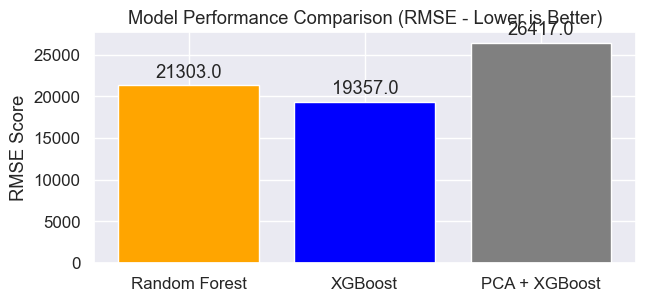

In [189]:
plt.figure(figsize=(7, 3))
models = list(model_results.keys())
rmses = list(model_results.values())
bars = plt.bar(models, rmses, color=['orange', 'blue', 'gray'])

plt.title("Model Performance Comparison (RMSE - Lower is Better)")
plt.ylabel("RMSE Score")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, round(yval, 0), ha='center', va='bottom')
plt.show()

In [191]:
print()
print(f"Min Price: {df['SalePrice'].min()}")
print(f"Max Price: {df['SalePrice'].max()}")
print(f"Mean Price: {df['SalePrice'].mean():.2f}")
print(f"Range (Max - Min): {df['SalePrice'].max() - df['SalePrice'].min()}")


Min Price: 34900
Max Price: 755000
Mean Price: 180624.10
Range (Max - Min): 720100
